# Block delivery from relays - EDA

#### Maria Silva, July 2025


## 1. Imports

In [1]:
import os
import json
import pytz
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sqlalchemy import create_engine

In [2]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))

In [3]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

In [4]:
def convert_slot_number_to_date_string(slot: int) -> str:
    slot_timestamp = slot * 12 + 1606824023
    slot_date = datetime.fromtimestamp(slot_timestamp, tz=pytz.timezone("UTC"))
    slot_date_str = slot_date.strftime("%Y-%m-%d %H:%M:%S")
    return slot_date_str

In [5]:
# Secrets for acessing xatu clickhouse and erigon
with open(os.path.join(repo_dir, "secrets.json"), "r") as file:
    secrets_dict = json.load(file)

# Credentials for xatu clickhouse
xatu_user = secrets_dict["xatu_username"]
xatu_pass = secrets_dict["xatu_password"]

db_url = db_url = (
        f"clickhouse+http://{xatu_user}:{xatu_pass}@"
        "clickhouse.xatu.ethpandaops.io:443/default?protocol=https"
    )

## 2. Data processing

### Ultrasound relay data

In [6]:
# Load raw data from ultrasound
ultra_file = os.path.join(
    repo_dir, "data", "relay", "ultrasound_payload_publish_time_08_11_13_49.csv"
)
ultra_df = pd.read_csv(ultra_file)
ultra_df["request_datetime"] = pd.to_datetime(ultra_df["received_at"]).dt.tz_localize(
    None
)
ultra_df["publish_datetime"] = pd.to_datetime(
    ultra_df["time_before_publish"]
).dt.tz_localize(None)
ultra_df = ultra_df[ultra_df["is_ultra_sound_header"]]
ultra_df = ultra_df[["slot", "request_datetime", "publish_datetime"]]
ultra_df["source"] = "ultrasound"
ultra_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21110 entries, 0 to 25165
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   slot              21110 non-null  int64         
 1   request_datetime  21110 non-null  datetime64[ns]
 2   publish_datetime  21110 non-null  datetime64[ns]
 3   source            21110 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 824.6+ KB


In [7]:
print(ultra_df["slot"].nunique())
ultra_df["slot"].agg(["min", "max"])

21110


min    12243622
max    12293998
Name: slot, dtype: int64

### Titan relay data

In [8]:
# Load raw data from titan
titan_file = os.path.join(repo_dir, "data", "relay", "titan_block_timings_12243620_12294000.csv")
titan_df = pd.read_csv(titan_file)
titan_df = titan_df.rename(columns={"slot_number": "slot"})
titan_df["request_datetime"] = pd.to_datetime(titan_df["signed_block_received"])
titan_df["publish_datetime"] = pd.to_datetime(titan_df["publishing_block"])
titan_df = titan_df[["slot", "request_datetime", "publish_datetime"]]
titan_df["source"] = "titan"
titan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2709 entries, 0 to 2708
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   slot              2709 non-null   int64         
 1   request_datetime  2709 non-null   datetime64[ns]
 2   publish_datetime  2709 non-null   datetime64[ns]
 3   source            2709 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 84.8+ KB


In [9]:
print(titan_df["slot"].nunique())
titan_df["slot"].agg(["min", "max"])

2709


min    12243642
max    12293979
Name: slot, dtype: int64

### Flashbots relay data

In [10]:
fb_file = os.path.join(
    repo_dir, "data", "relay", "flashbots-relay-timing-until-aug4.csv"
)
fb_df = pd.read_csv(fb_file)
fb_df = fb_df[["slot", "msIntoSlot"]].rename(
    columns={"msIntoSlot": "slot_start_to_publish"}
)
fb_df["source"] = "flashbots"
fb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2975 entries, 0 to 2974
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   slot                   2975 non-null   int64 
 1   slot_start_to_publish  2975 non-null   int64 
 2   source                 2975 non-null   object
dtypes: int64(2), object(1)
memory usage: 69.9+ KB


In [11]:
print(fb_df["slot"].nunique())
fb_df["slot"].agg(["min", "max"])

2975


min    12243627
max    12293993
Name: slot, dtype: int64

### Slot times

In [12]:
# Define dates for queries
slot_start = int(min(ultra_df["slot"].min(), titan_df["slot"].min(),fb_df["slot"].min()))
slot_end = int(max(ultra_df["slot"].max(), titan_df["slot"].max(),fb_df["slot"].max()))
start_date_str = convert_slot_number_to_date_string(slot_start-2)
end_date_str = convert_slot_number_to_date_string(slot_end+2)
# Define and run query
query_str = f"""
    SELECT DISTINCT slot, slot_start_date_time AS slot_start_datetime
    FROM default.canonical_beacon_block FINAL
    WHERE slot_start_date_time BETWEEN toDateTime('{start_date_str}') AND toDateTime('{end_date_str}')
        AND meta_network_name = 'mainnet'
"""
engine = create_engine(db_url)
slot_start_df = pd.read_sql(query_str, con=engine)
slot_start_df["slot_start_datetime"] = pd.to_datetime(
    slot_start_df["slot_start_datetime"]
)
slot_start_df

,slot,slot_start_datetime
0,12259947,2025-07-31 06:29:47
1,12259948,2025-07-31 06:29:59
2,12259956,2025-07-31 06:31:35
3,12259960,2025-07-31 06:32:23
4,12259963,2025-07-31 06:32:59
...,...,...
50047,12290972,2025-08-04 13:54:47
50048,12290979,2025-08-04 13:56:11
50049,12290980,2025-08-04 13:56:23
50050,12290981,2025-08-04 13:56:35


### Join relay data

In [13]:
# Join data
relay_df = pd.concat([ultra_df, titan_df, fb_df], ignore_index=True).merge(
    slot_start_df, on="slot", how="inner"
)
# Compute times
## request_to_publish
relay_df["request_to_publish"] = (
    relay_df["publish_datetime"] - relay_df["request_datetime"]
).dt.total_seconds() * 1000
## slot_start_to_request
relay_df["slot_start_to_request"] = (
    relay_df["request_datetime"] - relay_df["slot_start_datetime"]
).dt.total_seconds() * 1000
## slot_start_to_publish
slot_start_to_publish_arr = (
    relay_df["publish_datetime"] - relay_df["slot_start_datetime"]
).dt.total_seconds() * 1000
relay_df["slot_start_to_publish"] = np.where(
    relay_df["source"] == "flashbots",
    relay_df["slot_start_to_publish"],
    slot_start_to_publish_arr,
)
# Get fastest publish by by slot
relay_df = (
    relay_df
    .sort_values(by="slot_start_to_publish", ascending=False)
    .groupby("slot")
    .first(skipna=False)
    .reset_index()
    .sort_values(by="slot")
)
relay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   slot                   25792 non-null  int64         
 1   request_datetime       23028 non-null  datetime64[ns]
 2   publish_datetime       23028 non-null  datetime64[ns]
 3   source                 25792 non-null  object        
 4   slot_start_to_publish  25792 non-null  float64       
 5   slot_start_datetime    25792 non-null  datetime64[ns]
 6   request_to_publish     23028 non-null  float64       
 7   slot_start_to_request  23028 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(1)
memory usage: 1.6+ MB


In [25]:
print(relay_df["slot"].nunique())
relay_df["slot"].agg(["min", "max"])

25792


min    12243622
max    12293998
Name: slot, dtype: int64

In [26]:
relay_df["slot_start_datetime"].agg(["min", "max"])

min   2025-07-29 00:04:47
max   2025-08-04 23:59:59
Name: slot_start_datetime, dtype: datetime64[ns]

In [15]:
relay_df.groupby("source").size()

source
flashbots      2764
titan          2463
ultrasound    20565
dtype: int64

## 3. Time to request distribution

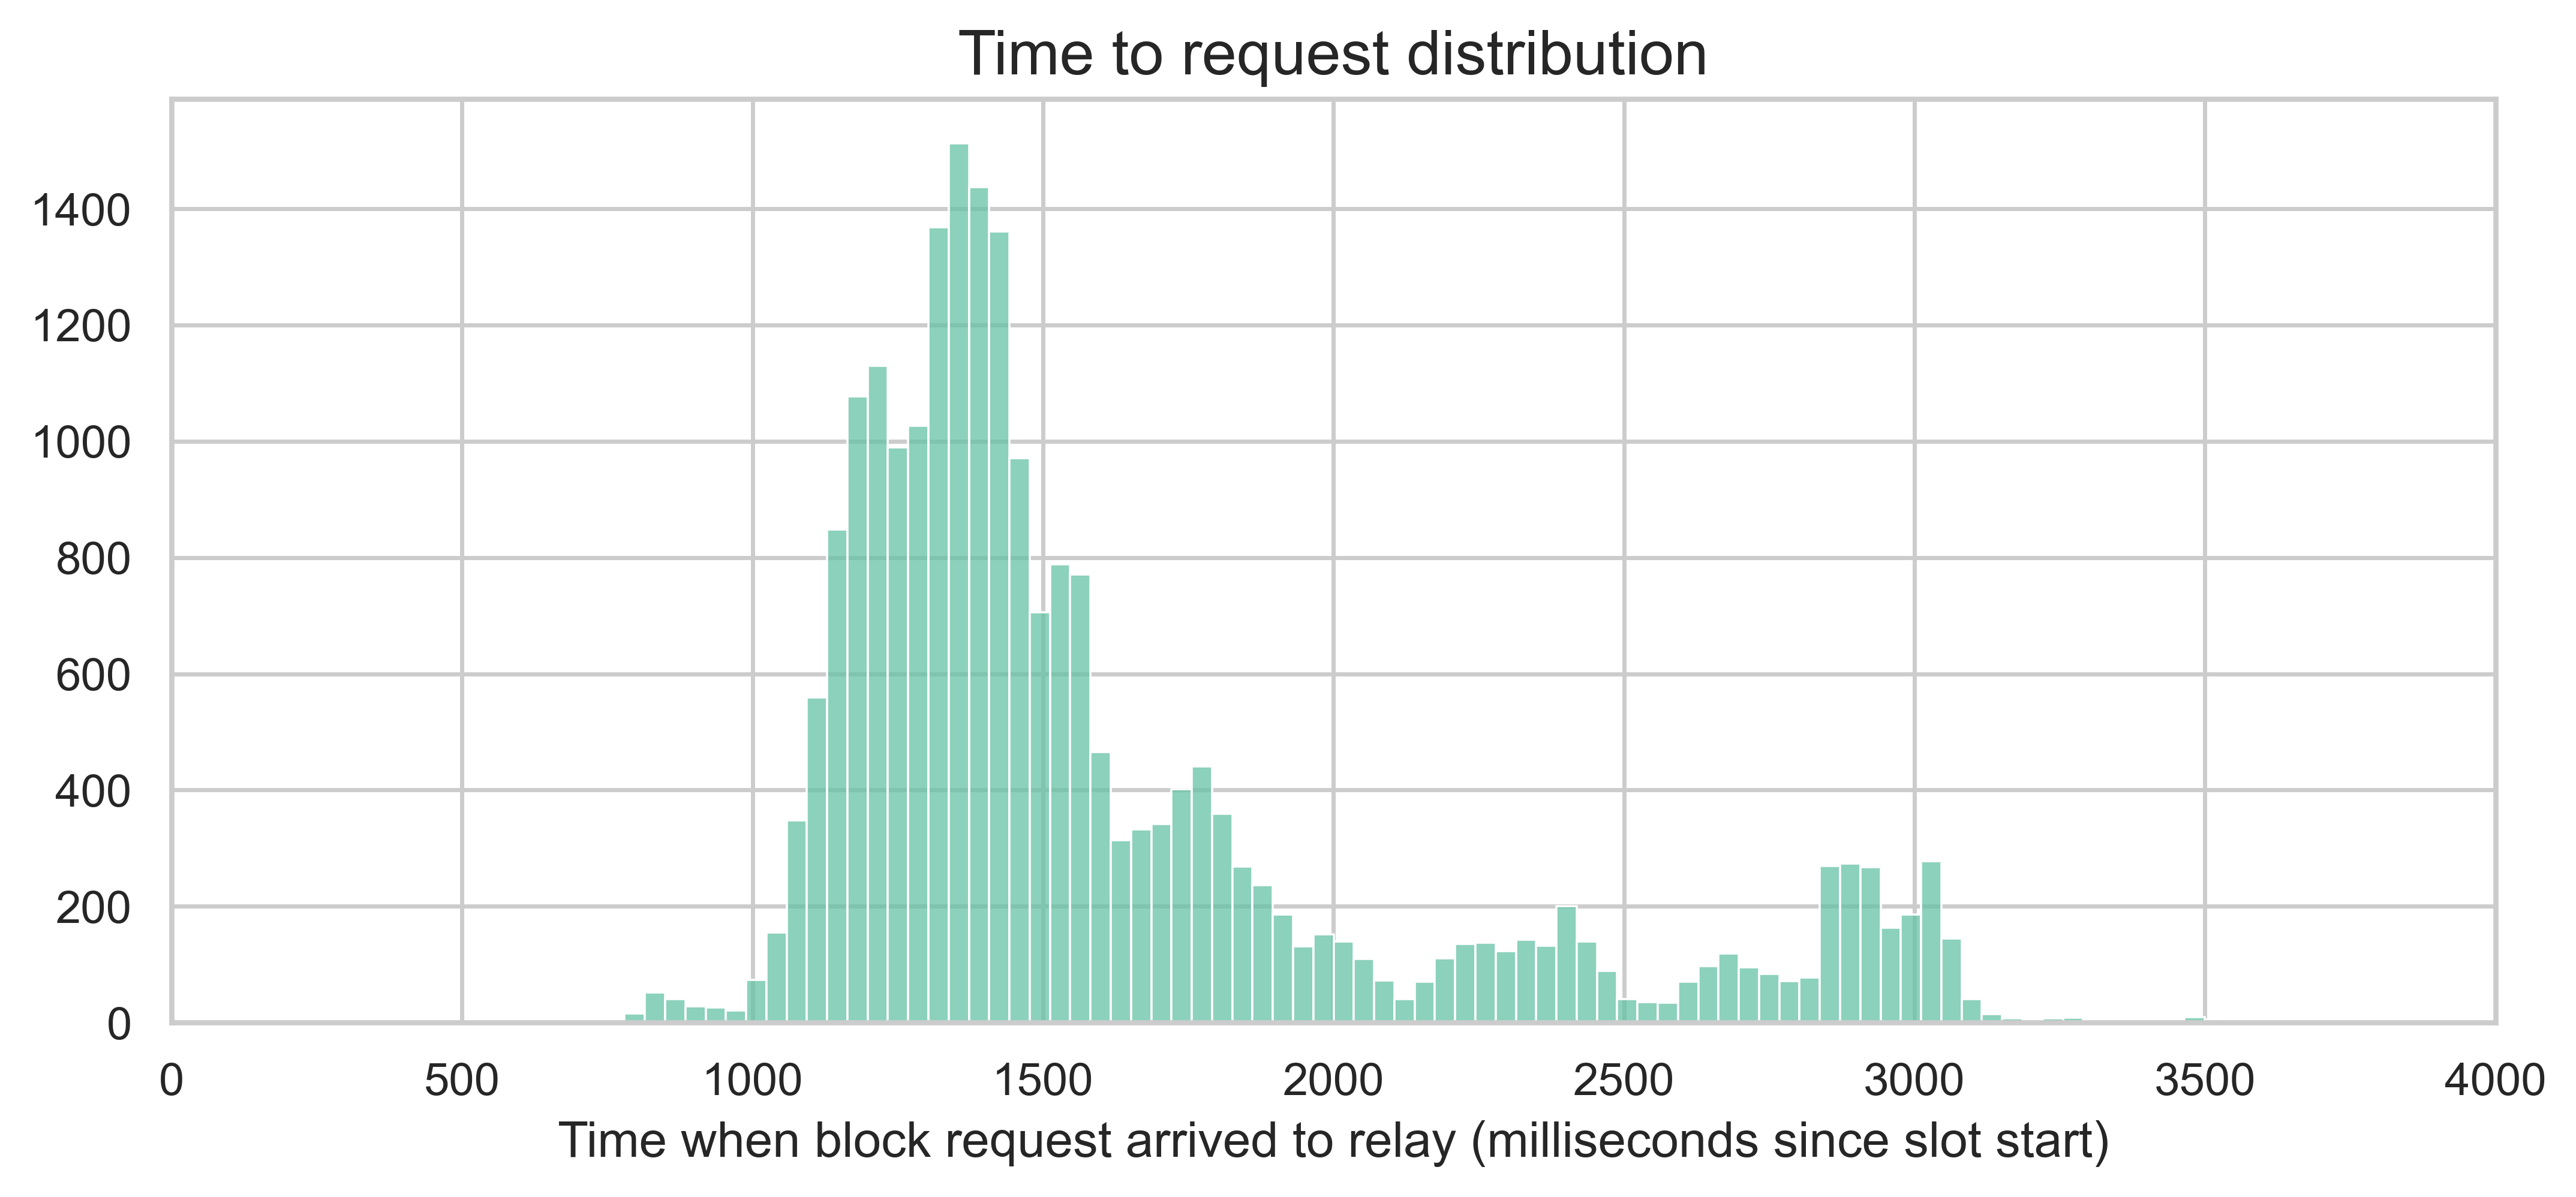

In [17]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=relay_df,
    x="slot_start_to_request",
    bins=100
)
plt.xlim(0,4000)
plt.title("Time to request distribution")
plt.ylabel("")
plt.xlabel("Time when block request arrived to relay (milliseconds since slot start)")
plt.show()

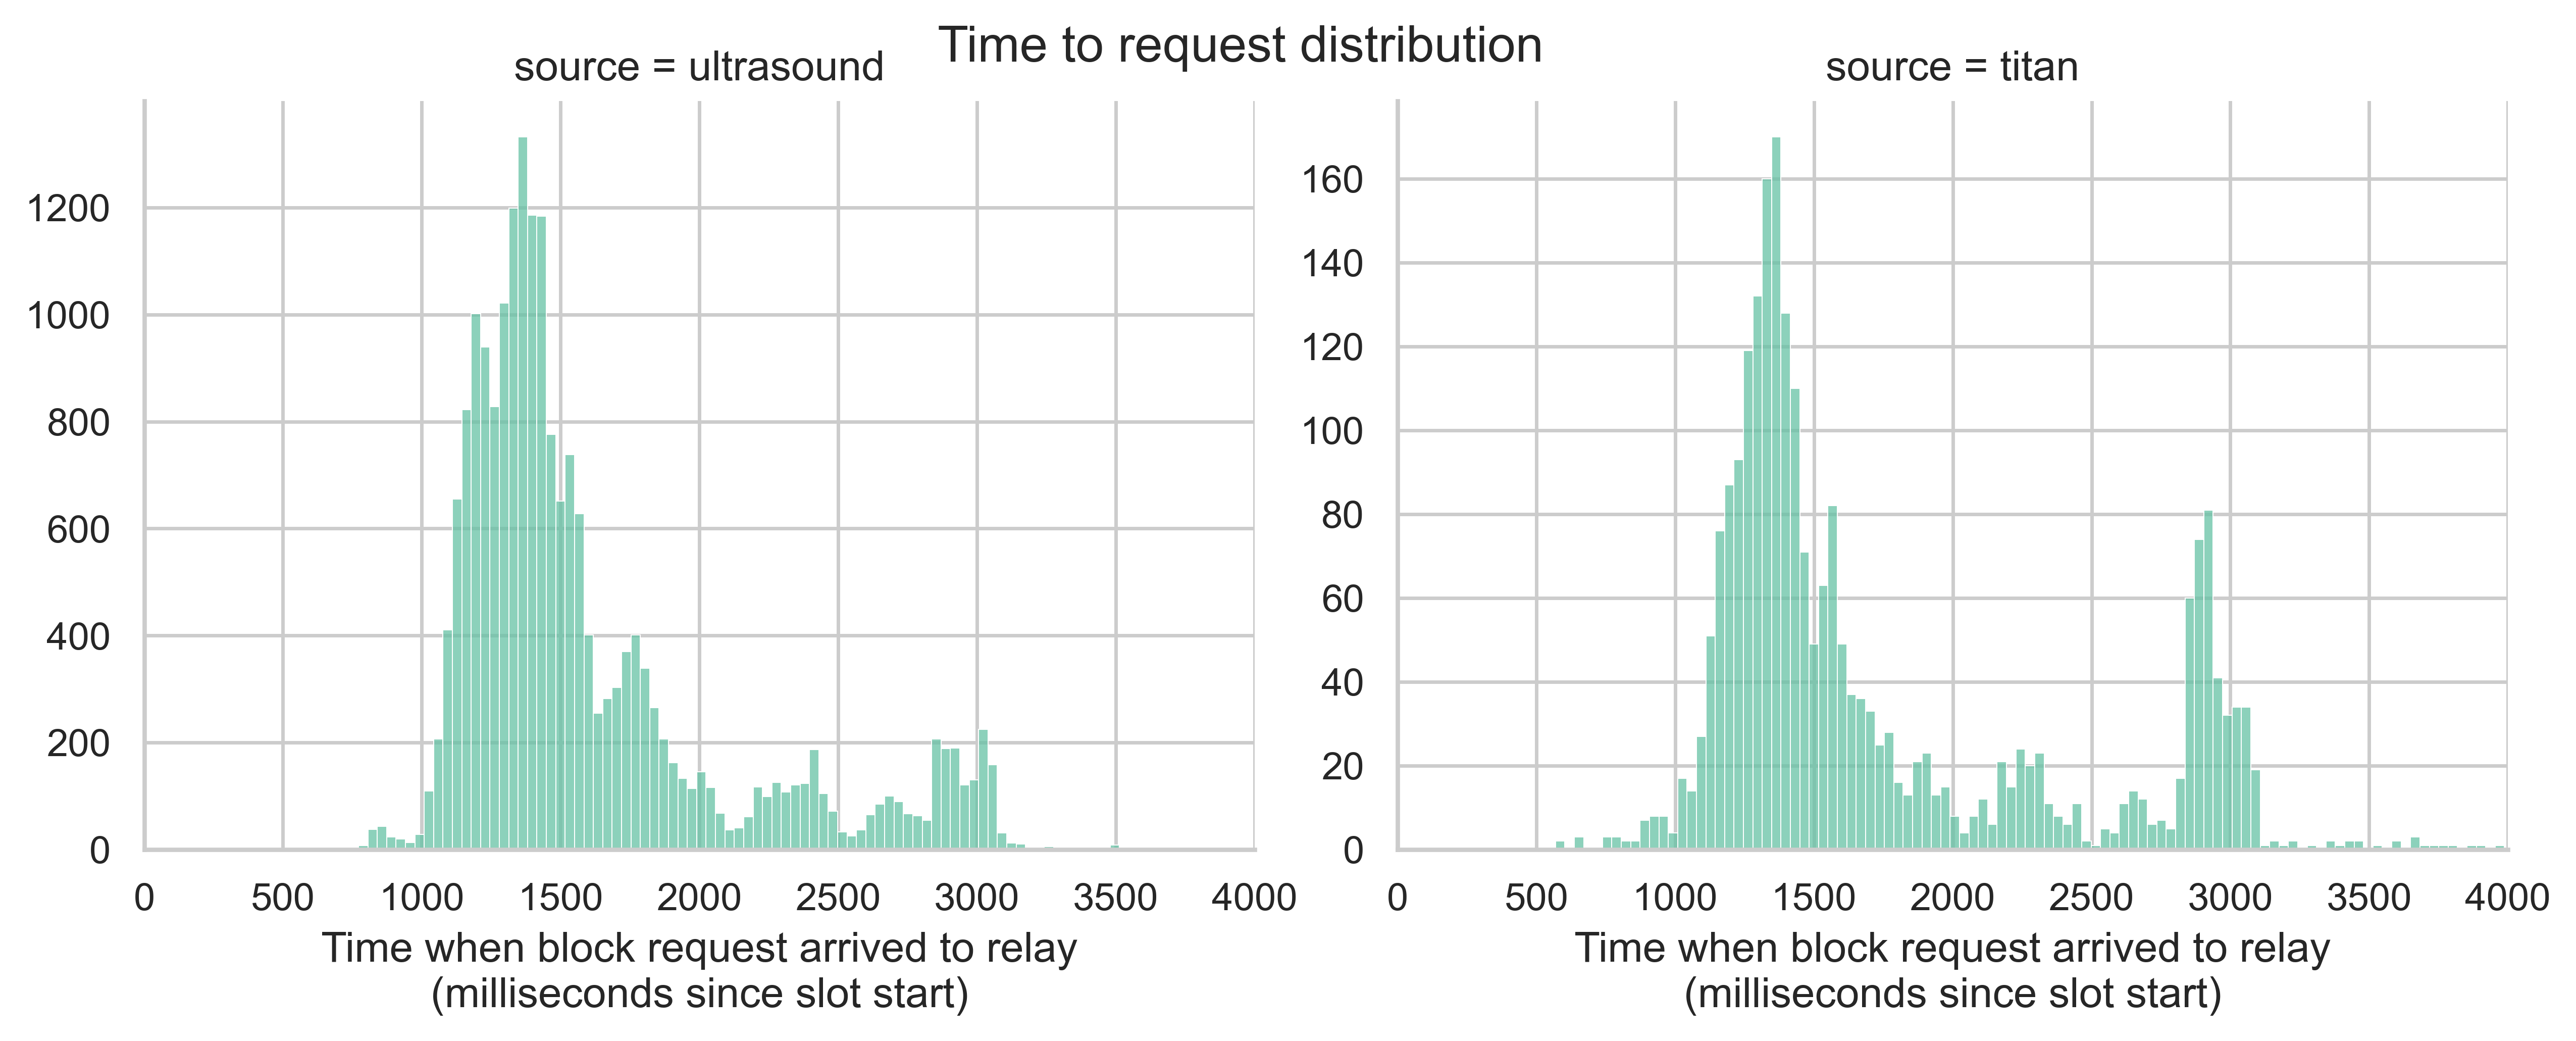

In [18]:

g = sns.displot(
    data=relay_df.dropna(),
    x="slot_start_to_request",
    col="source",
    kind="hist",
    height=4, aspect=1.3,
    facet_kws={"sharey":False}
)
g.set(xlim=(0,4000))
g.set_xlabels("Time when block request arrived to relay\n(milliseconds since slot start)")
g.set_ylabels("")
plt.suptitle("Time to request distribution")
plt.show()

In [19]:
relay_df["slot_start_to_request"].agg(["min", "max", "mean", "std"])

min      501.000000
max     3987.595231
mean    1623.965196
std      531.626049
Name: slot_start_to_request, dtype: float64

In [20]:
relay_df["slot_start_to_request"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    1283.000000
0.50    1426.157267
0.75    1765.000000
0.90    2610.000000
0.95    2909.000000
0.99    3053.000000
Name: slot_start_to_request, dtype: float64

## 4. Time to publish distribution

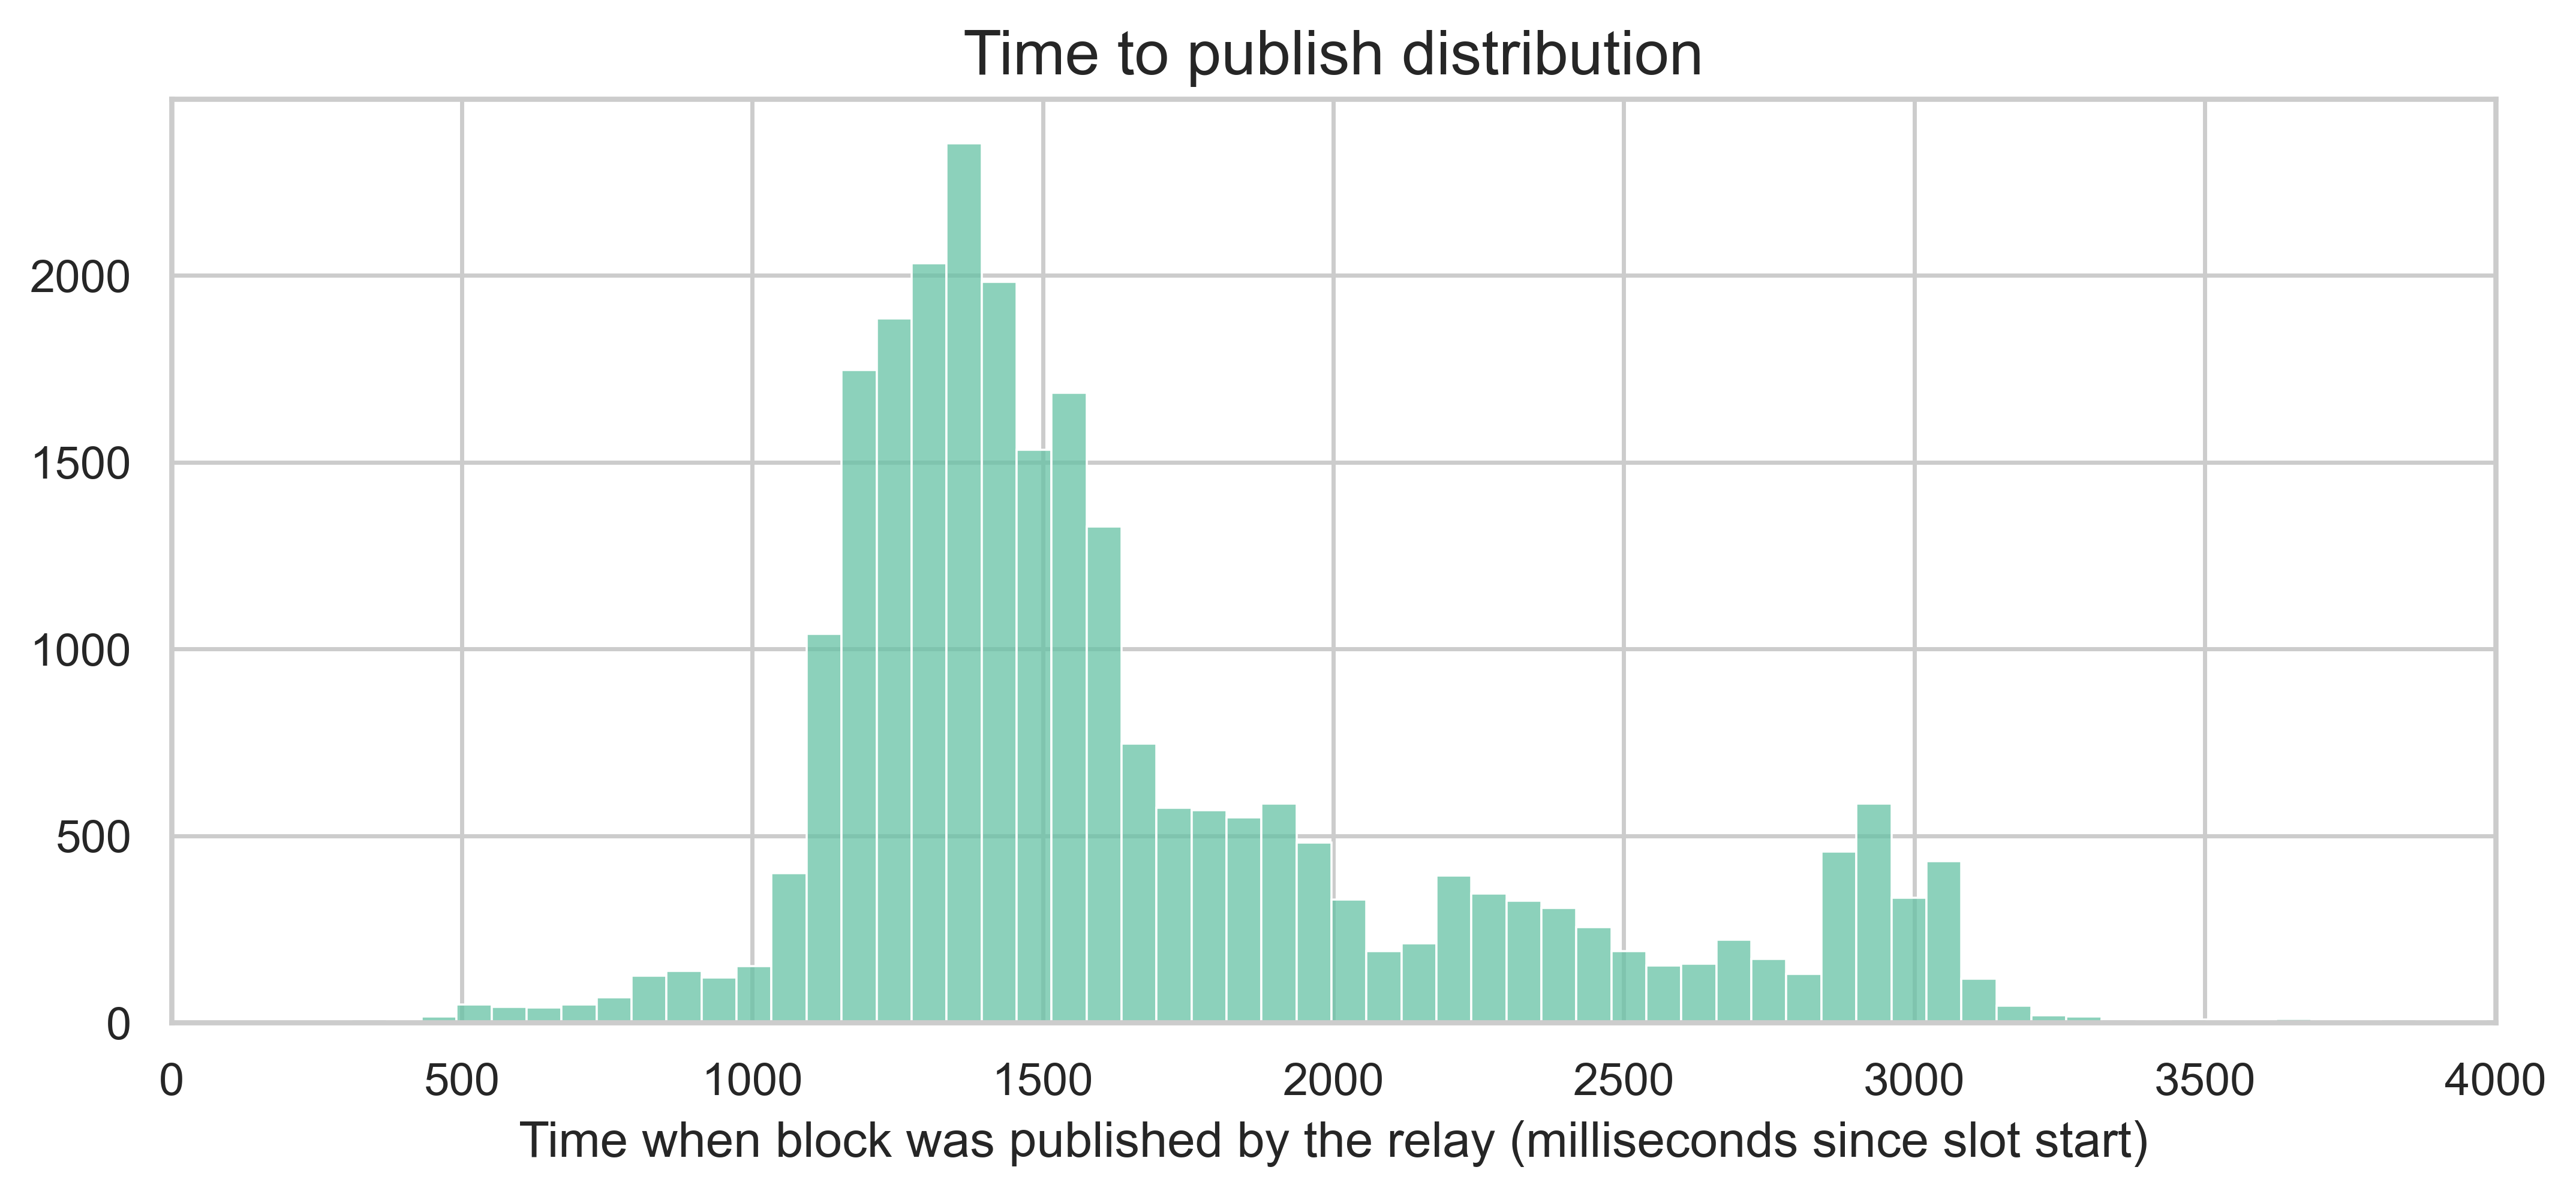

In [21]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=relay_df,
    x="slot_start_to_publish",
    bins=100
)
plt.xlim(0,4000)
plt.title("Time to publish distribution")
plt.ylabel("")
plt.xlabel("Time when block was published by the relay (milliseconds since slot start)")
plt.show()

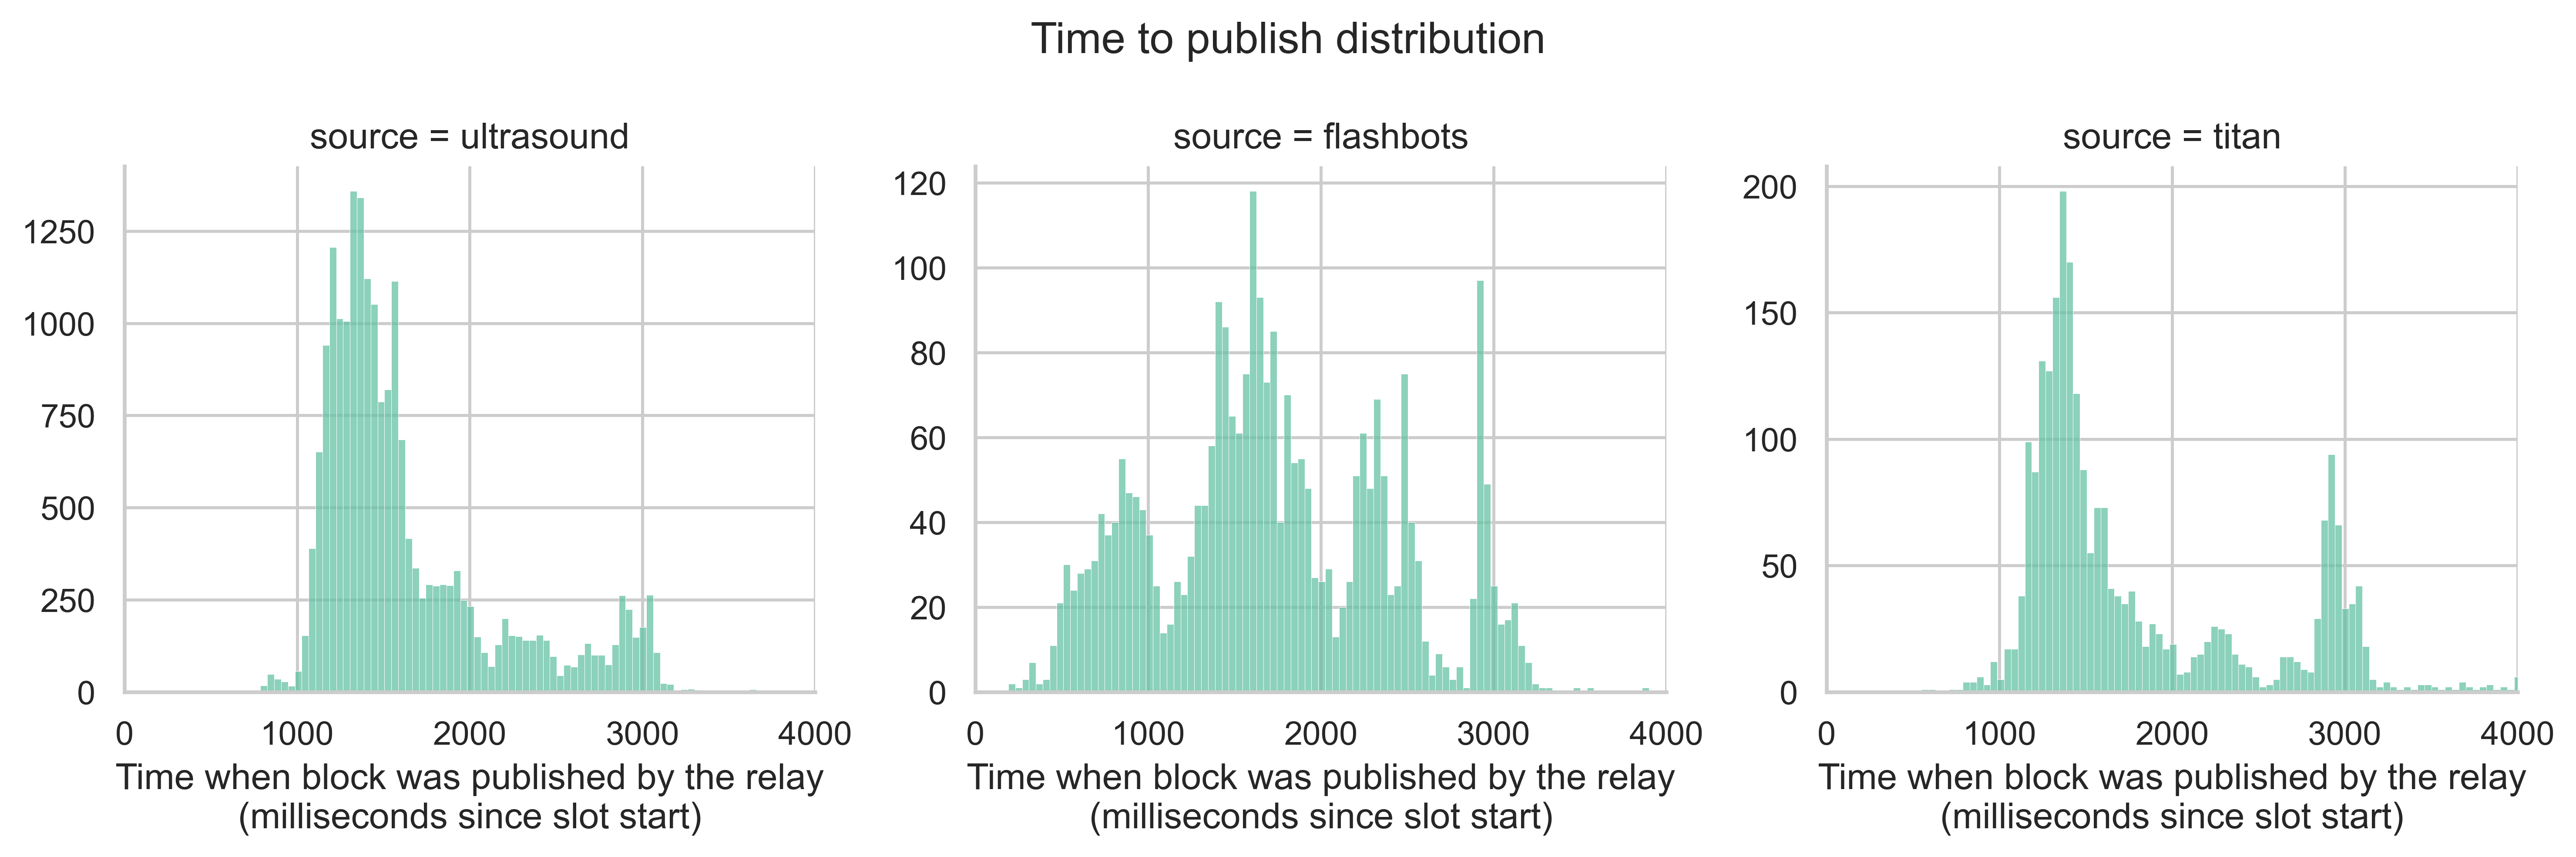

In [22]:

g = sns.displot(
    data=relay_df,
    x="slot_start_to_publish",
    col="source",
    kind="hist",
    height=4, aspect=1,
    facet_kws={"sharey":False}
)
g.set(xlim=(0,4000))
g.set_xlabels("Time when block was published by the relay\n(milliseconds since slot start)")
g.set_ylabels("")
plt.suptitle("Time to publish distribution")
plt.tight_layout()
plt.show()

In [23]:
relay_df["slot_start_to_publish"].agg(["min", "max", "mean", "std"])

min      190.000000
max     6212.682547
mean    1667.739287
std      565.555630
Name: slot_start_to_publish, dtype: float64

In [24]:
relay_df["slot_start_to_publish"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    1294.000000
0.50    1475.680114
0.75    1886.000000
0.90    2670.900000
0.95    2934.000000
0.99    3086.443664
Name: slot_start_to_publish, dtype: float64